In [1]:
# from google.colab import drive
# drive.mount('/content/drive')

# Unsupervised Clustering Project

This notebook provides a boilerplate structure for an unsupervised clustering project. It includes sections for data input, model training, and visualization of the results.

In [2]:
from typing import List, Optional, Sequence, Dict, Iterable
from __future__ import annotations
from dataclasses import dataclass

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans # Example clustering algorithm
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from scipy.stats import wasserstein_distance
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

import polars as pl
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output
from matplotlib import dates as mdates
from matplotlib.ticker import MaxNLocator
import matplotlib.pyplot as plt
import math

from tqdm.auto import tqdm
import warnings
warnings.filterwarnings("ignore", category=UserWarning)


## 1. Data Input

Specify the path to your parquet data file and load it into a pandas DataFrame.

In [3]:
def lazy_sample_parquet(
    path: str,
    fraction: float = 0.05,
    seed: int = 42,
    columns: list[str] | None = None,
    stratify_col: str | None = None,
) -> pl.DataFrame:
    """
    Low-memory sampling loader that works even if LazyFrame.sample() isn't available.
    - Loads a small random subset of rows directly from disk.
    - fraction = fraction of total rows to load (0–1)
    - columns = list of columns to read (for column pruning)
    - stratify_col = optional column to preserve distribution (lightweight, approximate)
    """
    # Step 1: Read just the schema to see what’s available
    schema = pl.read_parquet(path, n_rows=0).schema
    available_cols = list(schema.keys())
    if columns:
        columns = [c for c in columns if c in available_cols]
    else:
        columns = available_cols

    # Step 2: If stratification requested, read that column separately (small)
    if stratify_col and stratify_col in available_cols:
        small_col = pl.read_parquet(path, columns=[stratify_col])
        unique_vals = small_col[stratify_col].unique()
        n_groups = len(unique_vals)
        print(f"Stratifying by '{stratify_col}' across {n_groups:,} groups.")

        # Take a small fraction from each group (roughly)
        sampled_groups = []
        for val in unique_vals:
            mask = small_col[stratify_col] == val
            idx = np.where(mask)[0]
            n_take = max(1, int(len(idx) * fraction))
            chosen_idx = np.random.default_rng(seed).choice(idx, size=n_take, replace=False)
            sampled_groups.append(chosen_idx)
        take_indices = np.concatenate(sampled_groups)
        # This is only feasible if your file isn't > few hundred MBs
        return pl.read_parquet(path, columns=columns, row_indices=take_indices.tolist())

    # Step 3: No stratification → use chunked row-group sampling
    # Count total row groups without loading all data
    meta = pl.read_parquet(path, n_rows=0)
    # Determine rough number of rows per group (approx)
    total_rows = None
    try:
        # Some Polars versions expose this
        total_rows = meta.shape[0]
    except Exception:
        pass

    # Simple fallback: random row group fraction
    print(f"Sampling ≈{fraction*100:.1f}% of rows (columns={len(columns)})")
    df = pl.read_parquet(path, columns=columns)
    n = df.height
    take_n = int(max(1, n * fraction))
    idx = np.random.default_rng(seed).choice(n, take_n, replace=False)
    sample_df = df[idx]
    print(f"Loaded {sample_df.height:,} rows out of {n:,}")
    return sample_df


## 2. Data Preprocessing and Training

Perform necessary data preprocessing steps (e.g., scaling, feature selection) and then train your chosen unsupervised clustering model.

## Split the data for supervised / unsupervised training

In [4]:
def split_for_supervised_unsupervised(
    df: pl.DataFrame,
    test_size: float = 0.5,
    random_state: int = 42
) -> tuple[pl.DataFrame, pl.DataFrame]:
    """
    Randomly split a Polars DataFrame into two disjoint parts:
    one for supervised and one for unsupervised learning.
    """
    # Convert just indices for speed & reproducibility
    indices = np.arange(df.height)
    idx_train, idx_unsup = train_test_split(
        indices, test_size=test_size, random_state=random_state, shuffle=True
    )

    df_supervised = df[idx_train]
    df_unsupervised = df[idx_unsup]

    print(f"Split complete:")
    print(f"  Supervised subset:   {df_supervised.height:,} rows")
    print(f"  Unsupervised subset: {df_unsupervised.height:,} rows")

    return df_supervised, df_unsupervised


### PCA

In [5]:
def _prep_features(
    df: pl.DataFrame,
    feature_cols: List[str],
    standardize: bool = True,
    dtype: np.dtype = np.float32,
) -> np.ndarray:
    """
    Extract features from a Polars DF, fill nulls, cast to dtype, and (optionally) standardize.
    Returns a NumPy array without round-tripping through pandas.
    """
    X = (
        df.select([pl.col(c).cast(pl.Float32).fill_null(0.0) for c in feature_cols])
          .to_numpy()  # zero-copy from Polars to NumPy when possible
          .astype(dtype, copy=False)
    )
    if standardize:
#         X = StandardScaler(copy=False).fit_transform(X)  # in-place when possible
        X = StandardScaler(copy=True).fit_transform(X)
    return X

def apply_pca_preprocessing(
    df: pl.DataFrame,
    numeric_features: list[str],
    n_components: float = 0.95,
    standardize: bool = True,
) -> tuple[pl.DataFrame, PCA, list[str]]:
    """
    Apply PCA in NumPy space and append components back to the Polars DF.
    Avoid pandas, use float32.
    """
    X = _prep_features(df, numeric_features, standardize=standardize, dtype=np.float32)
    pca = PCA(n_components=n_components, svd_solver="full", random_state=42)
    Z = pca.fit_transform(X).astype(np.float32, copy=False)

    pca_cols = [f"pca_component_{i+1}" for i in range(Z.shape[1])]
    pca_df = pl.DataFrame(Z, schema=pca_cols)          # zero-copy into Polars
    result_df = pl.concat([df, pca_df], how="horizontal")

    print(f"PCA reduced {len(numeric_features)} → {len(pca_cols)} comps "
          f"(explained={pca.explained_variance_ratio_.sum():.3f})")
    return result_df, pca, pca_cols

In [6]:
def perform_clustering_from_X(
    X: np.ndarray,
    df: pl.DataFrame,
    n_clusters: int,
    random_state: int = 42,
    n_init: int | str = "auto",
    method: str = "kmeans",
    distance_threshold: float | None = None
) -> pl.DataFrame:
    if method == "kmeans":
        km = KMeans(
            n_clusters=n_clusters,
            random_state=random_state,
            n_init=n_init,
            algorithm="elkan",  # faster for Euclidean
        )
        labels = km.fit_predict(X)
        print(f"KMeans inertia: {km.inertia_:.2f}")
    
    elif method == "ward":
        # Step 1: Compute linkage matrix
        Z = linkage(X, method="ward")

        # Step 2: Auto-select clusters using distance threshold
        if distance_threshold is not None:
            labels = fcluster(Z, t=distance_threshold, criterion="distance") - 1
            print(f"Ward linkage: {len(set(labels))} clusters found using distance threshold = {distance_threshold}")
        else:
            raise ValueError("For Ward linkage, please provide a distance_threshold to auto-select clusters.")
    
    else:
        raise ValueError(f"Unsupported method: {method}. Choose 'kmeans' or 'ward'.")

    return df.with_columns(pl.Series("cluster", labels))


def perform_clustering(df: pl.DataFrame, feature_cols: List[str], n_clusters: int = 5) -> pl.DataFrame:
    X = _prep_features(df, feature_cols, standardize=True, dtype=np.float32)
    out = perform_clustering_from_X(X, df, n_clusters=n_clusters)
    # Optional: distribution
    counts = out.group_by("cluster").len().sort("cluster")
    print("\nCluster distribution:")
    for row in counts.iter_rows():
        cid, cnt = row
        print(f"  Cluster {cid}: {cnt:,} points ({cnt / df.height * 100:.1f}%)")
    return out


#%%
def analyze_clusters(df: pl.DataFrame, feature_cols: List[str], cluster_col: str = "cluster") -> pl.DataFrame:
    """
    Analyze cluster characteristics

    Args:
        df: DataFrame with cluster assignments
        feature_cols: Features used for clustering
        cluster_col: Name of cluster column

    Returns:
        DataFrame with cluster statistics
    """

    print(f"\nAnalyzing clusters using features: {feature_cols}")

    # Calculate cluster statistics
    cluster_stats = df.group_by(cluster_col).agg([
        pl.len().alias("count"),
        *[pl.col(col).mean().alias(f"{col}_mean") for col in feature_cols],
        *[pl.col(col).std().alias(f"{col}_std") for col in feature_cols],
        *[pl.col(col).min().alias(f"{col}_min") for col in feature_cols],
        *[pl.col(col).max().alias(f"{col}_max") for col in feature_cols]
    ]).sort(cluster_col)

    print("\nCluster Statistics:")
    print(cluster_stats)

    return cluster_stats


In [7]:
def _nice_grid(n):
    if n <= 1: return (1, 1)
    cols = int(np.ceil(np.sqrt(n)))
    rows = int(np.ceil(n / cols))
    return rows, cols

def to_pandas_minimal(df: pl.DataFrame, cols: list[str], label_col: str) -> pd.DataFrame:
    """
    Polars -> pandas for a small column subset:
      • dedupe requested names (order preserved)
      • tolerate duplicate column names
      • cast label to categorical
    """
    # 1) dedupe requested names
    cols = list(dict.fromkeys(cols))

    # 2) select and convert (no 'copy=' — not supported in some pyarrow versions)
    #    Optionally disable extension arrays to keep dtypes simple.
    out = df.select(cols).to_pandas(use_pyarrow_extension_array=False)

    # 3) if upstream duplicates slipped in, drop dup columns
    if out.columns.duplicated().any():
        out = out.loc[:, ~out.columns.duplicated()].copy()

    # 4) make label categorical
    if label_col in out.columns:
        out[label_col] = pd.Categorical(out[label_col])

    return out


def build_plot_cols(feature_set: list[str], label_col: str = "cluster", max_feats: int = 8) -> list[str]:
    """label first, then up to max_feats features (excluding label if present)."""
    feats = [c for c in feature_set if c != label_col][:max_feats]
    return [label_col] + feats


def regime_dashboard_windows(
    df: pd.DataFrame,
    label_col: str,
    candidate_columns=None,
    max_charts: int = 8,
    title_prefix: str = "Regime Characteristics Over Time",
    palette=None,
    include_object_date_guess: bool = False,
):
    if label_col not in df.columns:
        raise ValueError(f"label_col '{label_col}' not found in dataframe.")

    # Candidate axes
    if candidate_columns is None:
        numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
        dt_cols = df.select_dtypes(include=["datetime64[ns]", "datetime64[ns, UTC]", "datetimetz"]).columns.tolist()
        obj_date_like = []
        if include_object_date_guess:
            for c in df.select_dtypes(include=["object"]).columns.tolist():
                try:
                    pd.to_datetime(df[c].dropna().astype(str).head(5), errors="raise")
                    obj_date_like.append(c)
                except Exception:
                    pass
        candidate_columns = list(dict.fromkeys(dt_cols + obj_date_like + numeric_cols))
    if not candidate_columns:
        raise ValueError("No candidate columns found. Provide candidate_columns or check your dataframe dtypes.")

    # Do not allow the label column to be used as X/Y axis
    axis_options = [c for c in candidate_columns if c != label_col]
    if not axis_options:
        raise ValueError("No numeric/datetime columns available for axes (after excluding label column).")

    # Regime colors
    regimes = pd.Categorical(df[label_col])
    cats = list(regimes.categories)
    if palette is None:
        base = plt.cm.tab10.colors if len(cats) <= 10 else plt.cm.tab20.colors
        color_map = {cat: base[i % len(base)] for i, cat in enumerate(cats)}
    else:
        base = plt.cm.tab10.colors
        color_map = {cat: palette.get(cat, base[i % len(base)]) for i, cat in enumerate(cats)}

    # --- Widgets ---
    n_charts = widgets.IntSlider(value=min(4, max(1, len(axis_options)//2)),
                                 min=1, max=max(1, max_charts), step=1,
                                 description="Windows", continuous_update=False)
    width_slider  = widgets.IntSlider(value=15, min=8, max=24, step=1, description="Fig width",  continuous_update=False)
    height_slider = widgets.IntSlider(value=10, min=6, max=20, step=1, description="Fig height", continuous_update=False)
    size_slider   = widgets.IntSlider(value=20, min=5, max=80, step=1, description="Marker size", continuous_update=False)
    alpha_slider  = widgets.FloatSlider(value=0.6, min=0.05, max=1.0, step=0.05, description="Alpha", continuous_update=False)
    title_text    = widgets.Text(value=title_prefix, description="Suptitle", continuous_update=False)

    max_xticks    = widgets.IntSlider(value=6, min=3, max=15, step=1, description="Max X ticks", continuous_update=False)
    rotate_xticks = widgets.IntSlider(value=30, min=0, max=90, step=5, description="Rotate X°", continuous_update=False)
    concise_dates = widgets.Checkbox(value=True, description="Concise datetime format")

    selectors_box = widgets.VBox()

    def make_xy_row(i):
        return widgets.HBox([
            widgets.Dropdown(options=axis_options,
                             value=axis_options[min(i, len(axis_options)-1)],
                             description=f"X{i+1}", layout=widgets.Layout(width="50%")),
            widgets.Dropdown(options=axis_options,
                             value=axis_options[(i+1) % len(axis_options)],
                             description=f"Y{i+1}", layout=widgets.Layout(width="50%")),
        ])

    def refresh_selectors(*_):
        selectors_box.children = [make_xy_row(i) for i in range(n_charts.value)]

    n_charts.observe(lambda change: refresh_selectors(), names="value")
    refresh_selectors()

    out = widgets.Output()

    def _is_datetime_series(s: pd.Series) -> bool:
        return pd.api.types.is_datetime64_any_dtype(s)

    def _format_axes(ax, x_series: pd.Series):
        if _is_datetime_series(x_series):
            locator = mdates.AutoDateLocator(minticks=3, maxticks=max_xticks.value)
            formatter = mdates.ConciseDateFormatter(locator) if concise_dates.value else mdates.AutoDateFormatter(locator)
            ax.xaxis.set_major_locator(locator)
            ax.xaxis.set_major_formatter(formatter)
        else:
            ax.xaxis.set_major_locator(MaxNLocator(nbins=max_xticks.value, prune='both'))
        for tick in ax.get_xticklabels():
            tick.set_rotation(rotate_xticks.value)
            tick.set_horizontalalignment("right" if rotate_xticks.value else "center")

    def render(*_):
        with out:
            clear_output(wait=True)

            k = n_charts.value
            rows, cols = _nice_grid(k)
            fig, axes = plt.subplots(rows, cols, figsize=(width_slider.value, height_slider.value))
            axes_list = [axes] if rows*cols == 1 else np.array(axes).reshape(-1).tolist()

            for i in range(k):
                ax = axes_list[i]
                x_col = selectors_box.children[i].children[0].value
                y_col = selectors_box.children[i].children[1].value

                # Deduplicate selected cols (prevents duplicate column name issues)
                cols_sel = [x_col, y_col, label_col]
                cols_sel = list(dict.fromkeys(cols_sel))
                valid = df[cols_sel].dropna()

                # Ensure label is a Series even if duplicate names exist upstream
                lab = valid[label_col]
                if isinstance(lab, pd.DataFrame):
                    lab = lab.iloc[:, 0]

                # Draw per-regime
                for cat in cats:
                    mask = (lab == cat)
                    if not mask.any():
                        continue
                    sub = valid.loc[mask]
                    ax.scatter(
                        sub[x_col].values, sub[y_col].values,
                        s=size_slider.value, alpha=alpha_slider.value,
                        c=[color_map[cat]], label=str(cat)
                    )

                ax.set_title(f"{x_col} vs {y_col}")
                ax.set_xlabel(x_col)
                ax.set_ylabel(y_col)
                ax.grid(True, alpha=0.3)

                # Apply smart tick formatting
                _format_axes(ax, valid[x_col])

            # Hide unused
            for j in range(k, rows*cols):
                axes_list[j].axis("off")

            # Shared legend
            fig.suptitle(f"{title_text.value} — {label_col}", y=0.995)
            handles, labels = [], []
            for ax in axes_list[:k]:
                h, l = ax.get_legend_handles_labels()
                handles += h; labels += l
            if handles:
                seen, h_u, l_u = set(), [], []
                for h, l in zip(handles, labels):
                    if l not in seen:
                        seen.add(l); h_u.append(h); l_u.append(l)
                fig.legend(
                    h_u, l_u, title=str(label_col),
                    loc="upper right", ncol=min(len(l_u), 5), bbox_to_anchor=(1, 1)
                )

            fig.tight_layout(rect=(0, 0, 1, 0.97))
            plt.subplots_adjust(bottom=0.12)
            plt.show()

    render_btn = widgets.Button(description="Render", button_style="primary", icon="refresh")
    render_btn.on_click(lambda _: render())

    controls_top = widgets.HBox([n_charts, size_slider, alpha_slider])
    controls_mid = widgets.HBox([max_xticks, rotate_xticks, concise_dates])
    controls_bottom = widgets.HBox([width_slider, height_slider, title_text])
    ui = widgets.VBox([controls_top, controls_mid, controls_bottom, selectors_box, render_btn, out])
    display(ui)
    return ui


In [8]:
@dataclass
class KScanResult:
    ks: List[int]
    inertia: List[float]
    silhouette: List[Optional[float]]
    calinski_harabasz: List[Optional[float]]
    davies_bouldin: List[Optional[float]]
    best_k: int
    best_by: Dict[str, int]   # per-metric winners
    w_distance: Optional[List[Optional[float]]] = None



## 3. Visualization

Visualize the clustering results to understand the formed clusters.

In [9]:
def plot_k_scan(res: KScanResult) -> None:
    """Render diagnostic plots for k selection."""
    ks = np.array(res.ks)

    # Inertia (Elbow)
    plt.figure(figsize=(7,5))
    plt.plot(ks, res.inertia, marker="o")
    plt.title("Elbow (Inertia) vs k")
    plt.xlabel("k")
    plt.ylabel("Inertia (lower is better)")
    plt.grid(True, alpha=0.3)
    plt.axvline(res.best_by.get("elbow_inertia", None), linestyle="--", alpha=0.6)
    plt.show()

    # Silhouette
    if any(v is not None for v in res.silhouette):
        plt.figure(figsize=(7,5))
        plt.plot(ks, [np.nan if v is None else v for v in res.silhouette], marker="o")
        plt.title("Silhouette Score vs k (higher is better)")
        plt.xlabel("k")
        plt.ylabel("Silhouette")
        plt.grid(True, alpha=0.3)
        if "silhouette" in res.best_by:
            plt.axvline(res.best_by["silhouette"], linestyle="--", alpha=0.6)
        plt.show()

    # Calinski–Harabasz
    if any(v is not None for v in res.calinski_harabasz):
        plt.figure(figsize=(7,5))
        plt.plot(ks, [np.nan if v is None else v for v in res.calinski_harabasz], marker="o")
        plt.title("Calinski–Harabasz Index vs k (higher is better)")
        plt.xlabel("k")
        plt.ylabel("Calinski–Harabasz")
        plt.grid(True, alpha=0.3)
        if "calinski_harabasz" in res.best_by:
            plt.axvline(res.best_by["calinski_harabasz"], linestyle="--", alpha=0.6)
        plt.show()

    # Davies–Bouldin
    if any(v is not None for v in res.davies_bouldin):
        plt.figure(figsize=(7,5))
        plt.plot(ks, [np.nan if v is None else v for v in res.davies_bouldin], marker="o")
        plt.title("Davies–Bouldin Index vs k (lower is better)")
        plt.xlabel("k")
        plt.ylabel("Davies–Bouldin")
        plt.grid(True, alpha=0.3)
        if "davies_bouldin" in res.best_by:
            plt.axvline(res.best_by["davies_bouldin"], linestyle="--", alpha=0.6)
        plt.show()

    if any(v is not None for v in res.silhouette) and any(v is not None for v in res.davies_bouldin):
        if res.w_distance is not None:
            wdist = np.array([np.nan if v is None else v for v in res.w_distance], dtype=float)
        else:
            # Fallback: recompute safely if older result object
            silh_vals = np.array([np.nan if v is None else float(v) for v in res.silhouette])
            dbs_vals  = np.array([np.nan if v is None else float(v) for v in res.davies_bouldin])
            valid = np.isfinite(silh_vals) & np.isfinite(dbs_vals)
            wdist = np.full_like(silh_vals, np.nan, dtype=float)
            if np.any(valid):
                s_min, s_max = np.nanmin(silh_vals[valid]), np.nanmax(silh_vals[valid])
                d_min, d_max = np.nanmin(dbs_vals[valid]),  np.nanmax(dbs_vals[valid])
                s_den = (s_max - s_min) if (s_max - s_min) > 0 else 1.0
                d_den = (d_max - d_min) if (d_max - d_min) > 0 else 1.0
                s_n = np.full_like(silh_vals, np.nan, dtype=float); s_n[valid]=(silh_vals[valid]-s_min)/s_den
                d_n = np.full_like(dbs_vals,  np.nan, dtype=float); d_n[valid]=(dbs_vals[valid]-d_min)/d_den
                wdist[valid] = np.sqrt((1 - s_n[valid])**2 + d_n[valid]**2)

        plt.figure(figsize=(7,5))
        plt.plot(np.array(res.ks), wdist, marker="o")
        plt.title("W-distance (Silhouette + Davies–Bouldin) vs k (lower is better)")
        plt.xlabel("k"); plt.ylabel("W-distance"); plt.grid(True, alpha=0.3)
        if "w_distance" in res.best_by:
            plt.axvline(res.best_by["w_distance"], linestyle="--", alpha=0.6)
        plt.show()

    # Summary
    print("Per-metric winners:", res.best_by)
    print(f"Suggested k (ensemble): {res.best_k}")

## 4. Choosing k (model selection for KMeans)
We'll scan k over a range and compute multiple unsupervised criteria:
- Inertia (Elbow)
- Silhouette Score (higher is better; requires k >= 2)
- Calinski–Harabasz (higher is better)
- Davies–Bouldin (lower is better)
We'll then plot the metrics and propose a "best k" based on an ensemble heuristic.



In [10]:
def _kneedle(x: np.ndarray, y: np.ndarray) -> int:
    """
    Very small 'knee' detector for the Elbow curve (inertia).
    Returns index of knee in y(x) by maximizing distance to line between endpoints.
    """
    # Normalize x, y to [0,1] to be scale-invariant
    x_n = (x - x.min()) / (x.max() - x.min() + 1e-12)
    y_n = (y - y.min()) / (y.max() - y.min() + 1e-12)

    p1 = np.array([x_n[0], y_n[0]])
    p2 = np.array([x_n[-1], y_n[-1]])
    v = p2 - p1
    v /= np.linalg.norm(v) + 1e-12

    # Per-point distance to line p1->p2
    dists = []
    for i in range(len(x_n)):
        p = np.array([x_n[i], y_n[i]])
        proj_len = np.dot(p - p1, v)
        proj = p1 + proj_len * v
        d = np.linalg.norm(p - proj)
        dists.append(d)
    return int(np.argmax(dists))


from joblib import Parallel, delayed
from threadpoolctl import threadpool_limits
from sklearn.cluster import MiniBatchKMeans

def scan_k(
    df: pl.DataFrame | None,
    feature_cols: List[str] | None,
    k_range: Iterable[int] = range(2, 13),
    *,
    X: np.ndarray | None = None,   # NEW: precomputed feature matrix
    standardize: bool = True,
    random_state: int = 42,
    n_init: int | str = "auto",
    w_alpha: float = 1.0,
    w_beta: float = 1.0,
    n_jobs: int = 1,
    silhouette_sample_size: Optional[int] = None,
    use_minibatch: bool = False,
    mbk_max_iter: int = 100,
) -> KScanResult:
    if X is None:
        assert df is not None and feature_cols is not None, "Provide df+feature_cols or X."
        X = _prep_features(df, feature_cols, standardize=standardize, dtype=np.float32)
    else:
        # assume X is already standardized/float32
        pass

    ks = list(k_range)
    KM = MiniBatchKMeans if use_minibatch else KMeans
    km_kwargs = dict(n_clusters=None, random_state=random_state, n_init=n_init)
    if not use_minibatch:
        km_kwargs["algorithm"] = "elkan"
    else:
        km_kwargs.update(dict(batch_size=4096, max_iter=mbk_max_iter, reassignment_ratio=0.01))

    def _one_k(k: int):
        # Avoid nested parallelism: give BLAS/OpenMP 1 thread inside each job
        with threadpool_limits(limits=1):
            km = KM(**{**km_kwargs, "n_clusters": k})
            labels = km.fit_predict(X)
            inertia = float(km.inertia_)

            # metrics (guard degenerate labelings)
            if k >= 2 and len(set(labels)) > 1:
                sil = float(
                    silhouette_score(
                        X, labels,
                        sample_size=min(silhouette_sample_size, len(X)) if silhouette_sample_size else None,
                        random_state=random_state
                    )
                )
                ch  = float(calinski_harabasz_score(X, labels))
                db  = float(davies_bouldin_score(X, labels))
            else:
                sil = ch = db = None

            return k, inertia, sil, ch, db

    if n_jobs == 1:
        results = [_one_k(k) for k in ks]
    else:
        # threads, not processes (shared memory; no X pickling)
        results = Parallel(
            n_jobs=n_jobs,
            prefer="threads",
            require="sharedmem",
            verbose=10,
        )(delayed(_one_k)(k) for k in ks)
    # unpack in k order
    results = sorted(results, key=lambda t: t[0])
    inertia = [r[1] for r in results]
    silh    = [r[2] for r in results]
    chs     = [r[3] for r in results]
    dbs     = [r[4] for r in results]

    best_by: Dict[str, int] = {}
    knee_idx = _kneedle(np.array(ks), np.array(inertia))
    best_by["elbow_inertia"] = ks[knee_idx]

    if any(v is not None for v in silh):
        vals = np.array([v if v is not None else -np.inf for v in silh])
        best_by["silhouette"] = ks[int(np.nanargmax(vals))]

    if any(v is not None for v in chs):
        vals = np.array([v if v is not None else -np.inf for v in chs])
        best_by["calinski_harabasz"] = ks[int(np.nanargmax(vals))]

    if any(v is not None for v in dbs):
        vals = np.array([v if v is not None else np.inf for v in dbs])
        best_by["davies_bouldin"] = ks[int(np.nanargmin(vals))]

    wdist_list: Optional[List[Optional[float]]] = None
    if any(v is not None for v in silh) and any(v is not None for v in dbs):
        silh_arr = np.array([np.nan if v is None else float(v) for v in silh], dtype=float)
        dbs_arr  = np.array([np.nan if v is None else float(v) for v in dbs], dtype=float)
        valid = np.isfinite(silh_arr) & np.isfinite(dbs_arr)
        if np.any(valid):
            s_min, s_max = np.nanmin(silh_arr[valid]), np.nanmax(silh_arr[valid])
            d_min, d_max = np.nanmin(dbs_arr[valid]),  np.nanmax(dbs_arr[valid])
            s_den = (s_max - s_min) if (s_max - s_min) > 0 else 1.0
            d_den = (d_max - d_min) if (d_max - d_min) > 0 else 1.0
            silh_n = np.full_like(silh_arr, np.nan); silh_n[valid] = (silh_arr[valid]-s_min)/s_den
            dbs_n  = np.full_like(dbs_arr,  np.nan); dbs_n[valid]  = (dbs_arr[valid]-d_min)/d_den
            wdist = np.full_like(silh_arr, np.nan, dtype=float)
            wdist[valid] = np.sqrt((w_alpha*(1 - silh_n[valid]))**2 + (w_beta*dbs_n[valid])**2)
            wdist_list = [None if np.isnan(x) else float(x) for x in wdist]
            best_by["w_distance"] = ks[int(np.nanargmin(wdist))]

    votes = list(best_by.values())
    counts = pd.Series(votes).value_counts()
    best_k = int(counts.index[np.argmax(counts.values)])
    tied = counts[counts == counts.max()].index.tolist()
    if len(tied) > 1:
        best_k = int(min(tied))

    return KScanResult(
        ks=ks, inertia=inertia, silhouette=silh, calinski_harabasz=chs,
        davies_bouldin=dbs, best_k=best_k, best_by=best_by, w_distance=wdist_list
    )




def choose_k_and_cluster(
    df: pl.DataFrame,
    feature_cols: List[str],
    k_range: Iterable[int] = range(2, 13),
    standardize: bool = True,
    random_state: int = 42,
    n_init: int = 10,
    verbose: bool = True,
) -> tuple[pl.DataFrame, KScanResult]:
    """
    Convenience wrapper:
      1) Scan k
      2) Plot diagnostics
      3) Cluster with chosen k and return new DF + scan result
    """
    res = scan_k(
        df=df,
        feature_cols=feature_cols,
        k_range=k_range,
        standardize=standardize,
        random_state=random_state,
        n_init=n_init,
    )
    plot_k_scan(res)
    best_k = res.best_k

    if verbose:
        print(f"\nFitting final KMeans with k = {best_k}")

    X = _prep_features(df, feature_cols, standardize=standardize)
    km = KMeans(n_clusters=best_k, random_state=random_state, n_init=n_init)
    labels = km.fit_predict(X)

    out_df = df.with_columns(pl.Series("cluster", labels))
    return out_df, res

def auto_k_range(df: pl.DataFrame, feature_cols: list[str], max_cap: int = 13) -> range:
    """
    Automatically choose a reasonable k range based on dataset size and feature count.

    Heuristic:
      - Start at k = 2
      - Upper bound grows with sqrt(n_samples) but capped by both:
          * number of features (cannot exceed informative dimensions)
          * max_cap (default = 20)

    Returns:
        range object usable as k_range
    """
    n_samples = df.height
    n_features = len(feature_cols)

    # Use square-root heuristic (typical for exploratory clustering)
    upper = int(min(max_cap, max(3, math.sqrt(n_samples / 100)), n_features * 2))
    upper = max(upper, 4)  # ensure we scan at least up to 4

    print(f"Auto-selected k_range = range(2, {upper}) "
          f"(samples={n_samples:,}, features={n_features})")
    return range(2, upper)

## Example usage
- Option A: Use your raw features (e.g., implied_volatility, delta, gamma)
- Option B: Use PCA components to choose k in the reduced space.

In [11]:
from typing import Tuple, Iterable, Optional
from sklearn.metrics import adjusted_rand_score
from joblib import Parallel, delayed
from threadpoolctl import threadpool_limits

def _normalize_metrics(silh, dbs):
    print("Normalizing silhouette and Davies–Bouldin metrics...")
    silh_arr = np.array([np.nan if v is None else float(v) for v in silh], dtype=float)
    dbs_arr  = np.array([np.nan if v is None else float(v) for v in dbs], dtype=float)
    valid = np.isfinite(silh_arr) & np.isfinite(dbs_arr)
    s_n = np.full_like(silh_arr, np.nan, dtype=float)
    d_n = np.full_like(dbs_arr,  np.nan, dtype=float)
    if np.any(valid):
        s_min, s_max = np.nanmin(silh_arr[valid]), np.nanmax(silh_arr[valid])
        d_min, d_max = np.nanmin(dbs_arr[valid]),  np.nanmax(dbs_arr[valid])
        s_den = (s_max - s_min) if (s_max - s_min) > 0 else 1.0
        d_den = (d_max - d_min) if (d_max - d_min) > 0 else 1.0
        s_n[valid] = (silh_arr[valid] - s_min) / s_den        # target 1
        d_n[valid] = (dbs_arr[valid]  - d_min)  / d_den       # target 0
    return s_n, d_n, valid

def optimize_w_weights_by_stability_fast(
    ks_list: list[int],
    res,                     # KScanResult from scan_k (already computed)
    *,
    X: np.ndarray,           # precomputed standardized float32 features
    alphas=(0.25, 0.5, 1.0, 2.0, 4.0),
    betas=(0.25, 0.5, 1.0, 2.0, 4.0),
    random_state: int = 42,
    n_init: int | str = "auto",
    bootstraps: int = 8,
    sample_frac: float = 0.8,
    n_jobs_stability: int = 8,   # parallelize stability over k
):
    # 1) Normalize metrics once
    s_n, d_n, valid = _normalize_metrics(res.silhouette, res.davies_bouldin)
    if not np.any(valid):
        raise ValueError("No valid (silhouette, DB) pairs to optimize over.")

    ks_arr = np.array(ks_list)
    valid_idx = np.where(valid)[0]
    ks_valid = ks_arr[valid_idx]

    rng = np.random.RandomState(random_state)

    def top_k_candidates_by_wdist(res, m=5):
        print("Selecting top k candidates by W-distance...")
    # normalize once
        def _norm(arr):
            a = np.array([np.nan if v is None else float(v) for v in arr], dtype=float)
            v = np.isfinite(a)
            out = np.full_like(a, np.nan)
            if np.any(v):
                mn, mx = np.nanmin(a[v]), np.nanmax(a[v])
                den = (mx - mn) if (mx - mn) > 0 else 1.0
                out[v] = (a[v] - mn) / den
            return out, v

        s_n, v_s = _norm(res.silhouette)     # higher→1
        d_n, v_d = _norm(res.davies_bouldin) # lower→0
        valid = v_s & v_d
        ks = np.array(res.ks)
        one_minus_s = 1 - s_n[valid]
        d_vec = d_n[valid]
        wdist = np.sqrt(one_minus_s**2 + d_vec**2)
        ks_valid = ks[valid]
        order = np.argsort(wdist)
        return list(ks_valid[order[:m]]), {"wdist": wdist, "ks_valid": ks_valid}



    def stability_for_k(k: int) -> float:
        print(f"Computing stability for k={k}...")
        with threadpool_limits(limits=1):  # avoid oversubscription
            km0 = KMeans(n_clusters=k, random_state=random_state, n_init=n_init, algorithm="elkan")
            L0 = km0.fit_predict(X)
            n = X.shape[0]
            aris = []
            for b in range(bootstraps):
                idx = rng.choice(n, size=int(max(2, sample_frac * n)), replace=True)
                Xb = X[idx]
                kmb = KMeans(n_clusters=k, random_state=random_state + b + 1, n_init=n_init, algorithm="elkan")
                Lb = kmb.fit_predict(Xb)
                L0b = km0.predict(Xb)
                aris.append(adjusted_rand_score(L0b, Lb))
            return float(np.mean(aris)) if aris else np.nan

    # 2) Compute stability
    if len(ks_valid) == 1:
        cand_ks, _ = top_k_candidates_by_wdist(res, m=5)
        stability_scores = {int(cand_ks[0]): stability_for_k(int(cand_ks[0]))}
    else:
        print(f"B Computing stability for {len(ks_valid)} k values in parallel...")
        stab_vals = Parallel(n_jobs=n_jobs_stability, prefer="threads", require="sharedmem", verbose=0)(
            delayed(stability_for_k)(int(k)) for k in ks_valid
        )
        stability_scores = {int(k): float(v) for k, v in zip(ks_valid, stab_vals)}

    # 3) Grid search in O(len(α) * len(β) * |K|) with just vector ops
    tried = []
    best = {"alpha": None, "beta": None, "k": None, "score": -np.inf}

    # Precompute vectors used in distance for valid ks
    one_minus_s = 1.0 - s_n[valid]  # shape: |valid|
    d_vec = d_n[valid]

    for a in alphas:
        for b in betas:
            # wdist over valid ks
            wdist = np.sqrt((a * one_minus_s)**2 + (b * d_vec)**2)
            k_star = int(ks_valid[int(np.argmin(wdist))])
            score = float(stability_scores.get(k_star, np.nan))
            tried.append({"alpha": a, "beta": b, "k": k_star, "stability": score})
            if np.isfinite(score) and score > best["score"]:
                best.update({"alpha": a, "beta": b, "k": k_star, "score": score})

    summary = {"trials": tried, "best": best, "stability_by_k": stability_scores}
    print(f"Best stability {best['score']:.4f} at alpha={best['alpha']}, beta={best['beta']}, k={best['k']}")
    return best["alpha"], best["beta"], best["k"], summary


Sampling ≈0.1% of rows (columns=16)
Loaded 52,176 rows out of 52,176,345
PCA reduced 16 → 12 comps (explained=0.950)
Auto-selected k_range = range(2, 9) (samples=52,176, features=12)


[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done   1 tasks      | elapsed:    2.9s
[Parallel(n_jobs=8)]: Done   2 out of   7 | elapsed:    3.1s remaining:    7.7s
[Parallel(n_jobs=8)]: Done   3 out of   7 | elapsed:    3.1s remaining:    4.2s
[Parallel(n_jobs=8)]: Done   4 out of   7 | elapsed:    3.1s remaining:    2.3s
[Parallel(n_jobs=8)]: Done   5 out of   7 | elapsed:    3.1s remaining:    1.3s
[Parallel(n_jobs=8)]: Done   7 out of   7 | elapsed:    3.2s finished


Normalizing silhouette and Davies–Bouldin metrics...
B Computing stability for 7 k values in parallel...
Computing stability for k=2...
Computing stability for k=3...
Computing stability for k=4...
Computing stability for k=5...
Computing stability for k=6...
Computing stability for k=7...
Computing stability for k=8...
Best stability 0.7619 at alpha=0.25, beta=0.25, k=8
Stability-picked: α=0.25, β=0.25 → k*=8 (mean ARI=0.762)


[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done   1 tasks      | elapsed:    5.0s
[Parallel(n_jobs=8)]: Done   2 out of   7 | elapsed:    6.7s remaining:   16.9s
[Parallel(n_jobs=8)]: Done   3 out of   7 | elapsed:    7.5s remaining:   10.0s
[Parallel(n_jobs=8)]: Done   4 out of   7 | elapsed:    8.3s remaining:    6.2s
[Parallel(n_jobs=8)]: Done   5 out of   7 | elapsed:    8.8s remaining:    3.5s
[Parallel(n_jobs=8)]: Done   7 out of   7 | elapsed:    9.8s finished


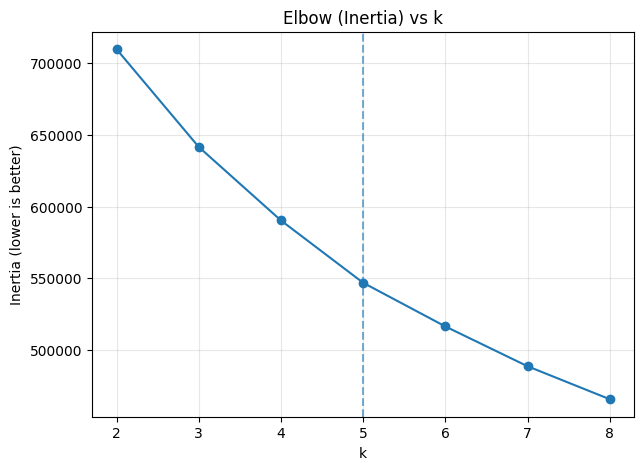

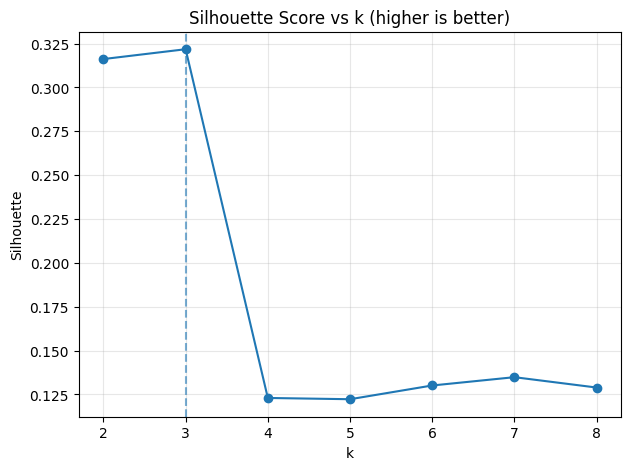

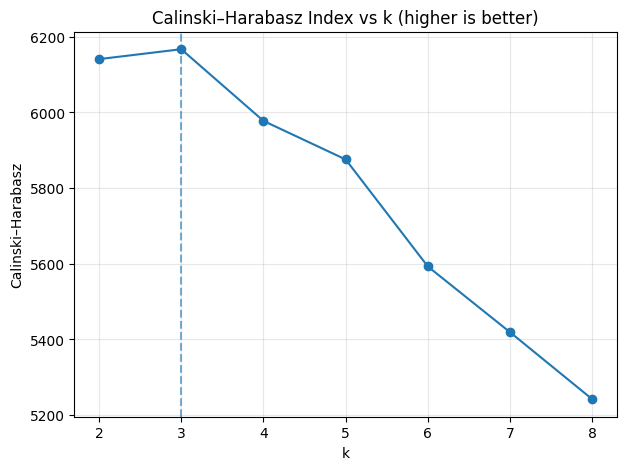

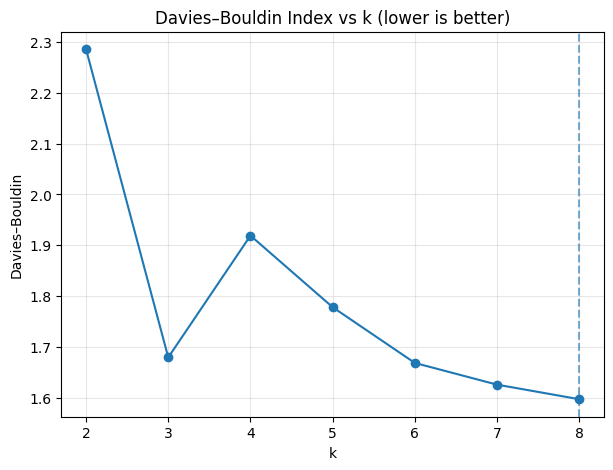

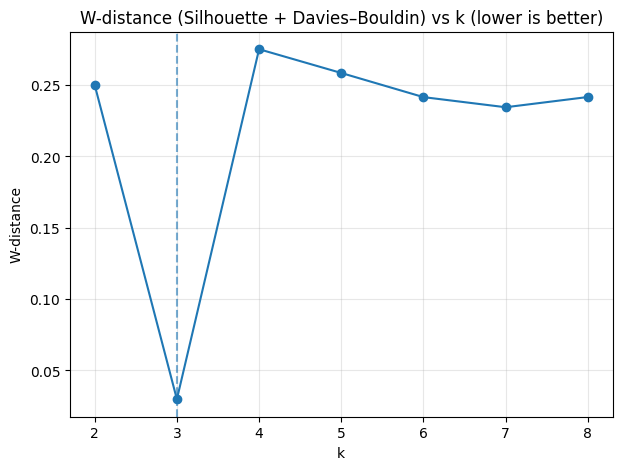

Per-metric winners: {'elbow_inertia': 5, 'silhouette': 3, 'calinski_harabasz': 3, 'davies_bouldin': 8, 'w_distance': 3}
Suggested k (ensemble): 3


[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done   1 tasks      | elapsed:    0.5s


KMeans inertia: 465715.03

Analyzing clusters using features: ['pca_component_1', 'pca_component_2', 'pca_component_3', 'pca_component_4', 'pca_component_5', 'pca_component_6', 'pca_component_7', 'pca_component_8', 'pca_component_9', 'pca_component_10', 'pca_component_11', 'pca_component_12']

Cluster Statistics:
shape: (8, 50)
┌─────────┬───────┬────────────┬────────────┬───┬────────────┬────────────┬────────────┬───────────┐
│ cluster ┆ count ┆ pca_compon ┆ pca_compon ┆ … ┆ pca_compon ┆ pca_compon ┆ pca_compon ┆ pca_compo │
│ ---     ┆ ---   ┆ ent_1_mean ┆ ent_2_mean ┆   ┆ ent_9_max  ┆ ent_10_max ┆ ent_11_max ┆ nent_12_m │
│ i32     ┆ u32   ┆ ---        ┆ ---        ┆   ┆ ---        ┆ ---        ┆ ---        ┆ ax        │
│         ┆       ┆ f32        ┆ f32        ┆   ┆ f32        ┆ f32        ┆ f32        ┆ ---       │
│         ┆       ┆            ┆            ┆   ┆            ┆            ┆            ┆ f32       │
╞═════════╪═══════╪════════════╪════════════╪═══╪════════════╪══

In [12]:
# 1) Load
# Usage - replace the original code

PARQUET_PATH = "./parquet/spy_historical_2005_2023.parquet"

numeric_features = [
    'impl_volatility', 'delta', 'theta', 'vega',
    'moneyness', 'volume', 'open_interest',
    'vol', 'volume_ma5', 'prc',
    'price_diff_1d',
    'price_diff_2d',
    'price_diff_3d',
    'price_diff_5d',
    'price_diff_8d',
    'price_diff_34d'
]


sample_df = lazy_sample_parquet(PARQUET_PATH, fraction=0.001, columns=numeric_features)

# 2) PCA
result, pca_obj, pca_cols = apply_pca_preprocessing(sample_df, numeric_features)

# 3) Precompute X once (reused by scan + final fit)
feature_set = pca_cols  # or raw numeric_features
X = _prep_features(result, feature_set, standardize=False, dtype=np.float32)

# 4) Auto k-range
k_range = auto_k_range(result, feature_set,max_cap=9)

res = scan_k(df=None, feature_cols=None, k_range=k_range, X=X,
             n_jobs=8, silhouette_sample_size=5000, use_minibatch=True, mbk_max_iter=100)

alpha, beta, k_star, info = optimize_w_weights_by_stability_fast(
    ks_list=list(res.ks),
    res=res,
    X=X,
    alphas=(0.25, 0.5, 1.0, 2.0, 4.0),
    betas=(0.25, 0.5, 1.0, 2.0, 4.0),
    n_init=20,
    bootstraps=6,          # you can lower this; it’s now multiplied by |K|, not by |K|*|grid|
    sample_frac=0.8,
    n_jobs_stability=8,
)
print(f"Stability-picked: α={alpha}, β={beta} → k*={k_star} (mean ARI={info['best']['score']:.3f})")

# 6) (Optional) plot diagnostics reusing X
kscan = scan_k(df=None, feature_cols=None, k_range=k_range, X=X, w_alpha=alpha, w_beta=beta, n_init=20, n_jobs=8, silhouette_sample_size=5000)
plot_k_scan(kscan)

best_spy_k_res = scan_k(df=None, feature_cols=None, k_range=[k_star], X=X,
             n_jobs=8, silhouette_sample_size=5000, use_minibatch=True, mbk_max_iter=100)

# 7) Final fit from X
clustered_auto_df = perform_clustering_from_X(X, result, n_clusters=k_star, n_init=20)

# 8) Analysis (all-Polars; no copies)
cluster_stats_auto = analyze_clusters(clustered_auto_df, feature_cols=feature_set, cluster_col="cluster")

# 9) Save once
clustered_auto_df.write_parquet("./parquet/clusted_auto_SPY.parquet")


In [13]:
# 1) decide which non-PCA columns you want available
extra_cols = [
    "prc", "volume", "open_interest",
    "impl_volatility", "delta", "theta",  # raw features
    # "date"  # include if you have a timestamp column
]

# 2) build the set of columns to carry into pandas
plot_cols = build_plot_cols(feature_set=pca_cols, label_col="cluster", max_feats=8)
plot_cols += [c for c in extra_cols if c not in plot_cols and c in clustered_auto_df.columns]

# 3) convert to pandas (with our robust helper from before)
df_plot = to_pandas_minimal(clustered_auto_df, plot_cols, label_col="cluster")

# (optional) if you added a timestamp column that came over as object, fix its dtype:
for dtc in ("date", "timestamp", "datetime"):
    if dtc in df_plot.columns and not pd.api.types.is_datetime64_any_dtype(df_plot[dtc]):
        df_plot[dtc] = pd.to_datetime(df_plot[dtc], errors="coerce")

# 4A) let the widget auto-discover axes (will now include your extras)
regime_dashboard_windows(df=df_plot, label_col="cluster")


Sampling ≈0.1% of rows (columns=16)
Loaded 20,204 rows out of 20,204,265
PCA reduced 16 → 13 comps (explained=0.967)
Auto-selected k_range = range(2, 9) (samples=20,204, features=12)


[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done   1 tasks      | elapsed:    2.3s
[Parallel(n_jobs=8)]: Done   2 out of   7 | elapsed:    2.4s remaining:    5.9s
[Parallel(n_jobs=8)]: Done   3 out of   7 | elapsed:    2.4s remaining:    3.1s
[Parallel(n_jobs=8)]: Done   4 out of   7 | elapsed:    2.4s remaining:    1.8s
[Parallel(n_jobs=8)]: Done   5 out of   7 | elapsed:    2.5s remaining:    1.0s
[Parallel(n_jobs=8)]: Done   7 out of   7 | elapsed:    2.5s finished


Normalizing silhouette and Davies–Bouldin metrics...
B Computing stability for 7 k values in parallel...
Computing stability for k=2...
Computing stability for k=3...
Computing stability for k=4...
Computing stability for k=5...
Computing stability for k=6...
Computing stability for k=7...
Computing stability for k=8...
Best stability 0.9777 at alpha=0.25, beta=0.25, k=2
QQQ: α=0.25, β=0.25 → k*=2 (mean ARI=0.978)


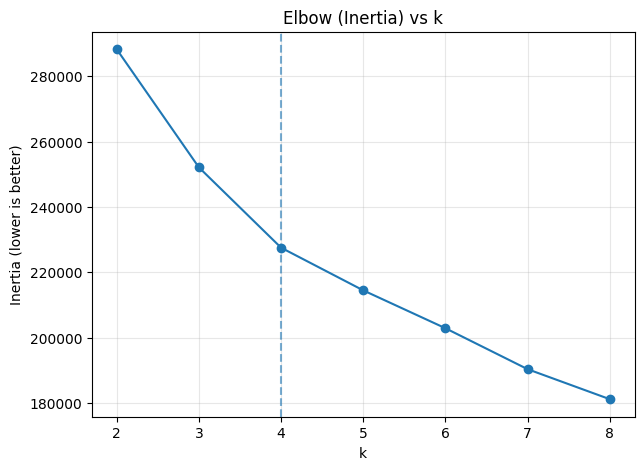

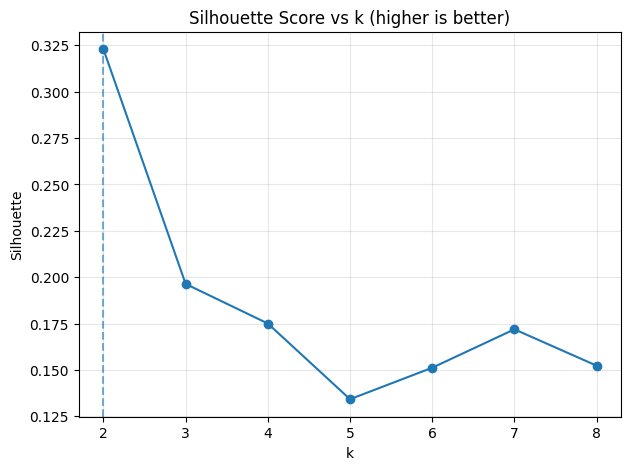

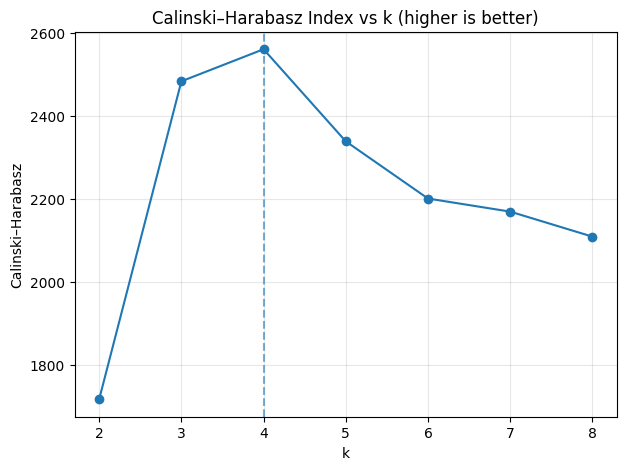

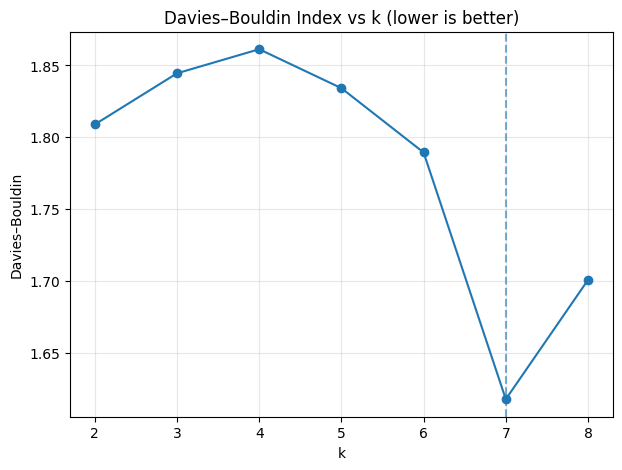

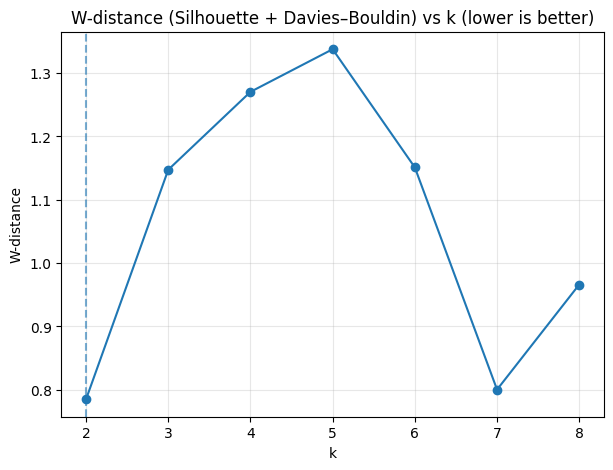

Per-metric winners: {'elbow_inertia': 4, 'silhouette': 2, 'calinski_harabasz': 4, 'davies_bouldin': 7, 'w_distance': 2}
Suggested k (ensemble): 2


[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done   1 tasks      | elapsed:    0.5s


KMeans inertia: 274037.66


In [14]:
# QQQ pipeline

path = "./parquet/qqq_historical_2005_2023.parquet"

# 1) Load
sample_qqq = lazy_sample_parquet(path, fraction=0.001, columns=numeric_features)

# 2) PCA (once)
result_qqq, pca_obj_qqq, pca_cols_qqq = apply_pca_preprocessing(sample_qqq, numeric_features)
# loadings_qqq = pd.DataFrame(pca_obj_qqq.components_, columns=numeric_features)
# loadings_qqq.index = [f'PC{i+1}' for i in range(loadings_qqq.shape[0])]
# print("PCA Loadings (each row = PC, each column = feature weight):")
# display(loadings_qqq.head())

# 3) Auto k-range
k_range = auto_k_range(result_qqq, feature_set,max_cap=9)

# 4) Precompute features once
X_qqq = _prep_features(result_qqq, pca_cols_qqq, standardize=False, dtype=np.float32)

# 5) Fast scan + weight search (cached stability)
res_qqq = scan_k(df=None, feature_cols=None, k_range=k_range, X=X_qqq,
                 n_jobs=8, silhouette_sample_size=5000, use_minibatch=True, mbk_max_iter=100)

alpha_qqq, beta_qqq, k_star_qqq, info_qqq = optimize_w_weights_by_stability_fast(
    ks_list=list(res_qqq.ks),
    res=res_qqq,
    X=X_qqq,
    alphas=(0.25, 0.5, 1.0, 2.0, 4.0),
    betas=(0.25, 0.5, 1.0, 2.0, 4.0),
    n_init=20,
    bootstraps=6,
    sample_frac=0.8,
    n_jobs_stability=8,
)
print(f"QQQ: α={alpha_qqq}, β={beta_qqq} → k*={k_star_qqq} (mean ARI={info_qqq['best']['score']:.3f})")

# (Optional) diagnostics using the chosen weights
plot_k_scan(res_qqq)

best_qqq_k_res = scan_k(df=None, feature_cols=None, k_range=[k_star_qqq], X=X_qqq,
                 n_jobs=8, silhouette_sample_size=5000, use_minibatch=True, mbk_max_iter=100)

# Final clustering from precomputed X
clustered_auto_qqq_df = perform_clustering_from_X(X_qqq, result_qqq, n_clusters=k_star_qqq, n_init=20)

#save clustered_auto_qqq_df to parquet
clustered_auto_qqq_df.write_parquet("./parquet/clustered_auto_qqq_df.parquet")

In [15]:

#load clustered_auto_qqq_df
# clustered_auto_qqq_df = pl.read_parquet("../drive/MyDrive/clustered_auto_qqq_df.parquet")

plot_cols = build_plot_cols(feature_set=pca_cols_qqq, label_col="cluster", max_feats=8)
plot_cols += [c for c in extra_cols if c not in plot_cols and c in clustered_auto_qqq_df.columns]
df_plot_qqq = to_pandas_minimal(clustered_auto_qqq_df, plot_cols, label_col="cluster")
for dtc in ("date", "timestamp", "datetime"):
    if dtc in df_plot_qqq.columns and not pd.api.types.is_datetime64_any_dtype(df_plot_qqq[dtc]):
        df_plot_qqq[dtc] = pd.to_datetime(df_plot_qqq[dtc], errors="coerce")
regime_dashboard_windows(df=df_plot_qqq, label_col="cluster")

In [16]:
def scan_ward_thresholds(
    X: np.ndarray,
    thresholds: list[float],
    sample_size: int | None = None,
    random_state: int = 42
):  
    Z = linkage(X, method="ward")
    silh, chs, dbs, wdists = [], [], [], []
    best_by = {}

    for t in thresholds:
        labels = fcluster(Z, t=t, criterion="distance") - 1
        if len(set(labels)) > 1:
            silh.append(silhouette_score(X, labels, sample_size=sample_size, random_state=random_state))
            chs.append(calinski_harabasz_score(X, labels))
            dbs.append(davies_bouldin_score(X, labels))

            # Wasserstein distance: average over clusters
            cluster_dists = []
            for i in np.unique(labels):
                cluster_points = X[labels == i]
                centroid = np.mean(cluster_points, axis=0)
                dist = wasserstein_distance(cluster_points.flatten(), centroid.flatten())
                cluster_dists.append(dist)
            wdists.append(float(np.mean(cluster_dists)))
        else:
            silh.append(None)
            chs.append(None)
            dbs.append(None)
            wdists.append(None)

    # Voting logic
    if any(v is not None for v in silh):
        vals = np.array([v if v is not None else -np.inf for v in silh])
        best_by["silhouette"] = thresholds[int(np.nanargmax(vals))]

    if any(v is not None for v in chs):
        vals = np.array([v if v is not None else -np.inf for v in chs])
        best_by["calinski_harabasz"] = thresholds[int(np.nanargmax(vals))]

    if any(v is not None for v in dbs):
        vals = np.array([v if v is not None else np.inf for v in dbs])
        best_by["davies_bouldin"] = thresholds[int(np.nanargmin(vals))]

    if any(v is not None for v in wdists):
        vals = np.array([v if v is not None else np.inf for v in wdists])
        best_by["wasserstein"] = thresholds[int(np.nanargmin(vals))]

    votes = list(best_by.values())
    counts = pd.Series(votes).value_counts()
    best_threshold = float(counts.index[np.argmax(counts.values)])
    tied = counts[counts == counts.max()].index.tolist()
    if len(tied) > 1:
        best_threshold = float(min(tied))

    print(f"Stability-picked Ward threshold = {best_threshold:.2f}")
    if best_by:
        print("Best-by votes:")
        for metric, threshold in best_by.items():
            print(f"  {metric:<20}: {threshold:.2f}")

    return {
        "thresholds": thresholds,
        "silhouette": silh,
        "calinski_harabasz": chs,
        "davies_bouldin": dbs,
        "wasserstein": wdists,
        "best_threshold": best_threshold,
        "best_by": best_by
    }

In [17]:
def optimize_w_weights_by_stability_ward(
    thresholds: list[float],
    res,  # result from scan_ward_thresholds
    *,
    X: np.ndarray,
    alphas=(0.25, 0.5, 1.0, 2.0, 4.0),
    betas=(0.25, 0.5, 1.0, 2.0, 4.0),
    random_state: int = 42,
    bootstraps: int = 8,
    sample_frac: float = 0.8,
    n_jobs_stability: int = 8,
):
    s_n, d_n, valid = _normalize_metrics(res["silhouette"], res["davies_bouldin"])

    if not np.any(valid):
        raise ValueError("No valid (silhouette, DB) pairs to optimize over.")

    thresholds_arr = np.array(res["thresholds"])
    thresholds_valid = thresholds_arr[valid]
    one_minus_s = 1.0 - s_n[valid]
    d_vec = d_n[valid]
    rng = np.random.RandomState(random_state)

    def stability_for_threshold(thresh: float) -> float:
        print(f"Computing stability for threshold={thresh:.2f}...")
        with threadpool_limits(limits=1):
            Z0 = linkage(X, method="ward")
            L0 = fcluster(Z0, t=thresh, criterion="distance") - 1
            n = X.shape[0]
            aris = []
            for b in range(bootstraps):
                idx = rng.choice(n, size=int(max(2, sample_frac * n)), replace=True)
                Xb = X[idx]
                Zb = linkage(Xb, method="ward")
                Lb = fcluster(Zb, t=thresh, criterion="distance") - 1
                L0b = fcluster(linkage(Xb, method="ward"), t=thresh, criterion="distance") - 1
                aris.append(adjusted_rand_score(L0b, Lb))
            return float(np.mean(aris)) if aris else np.nan

    print(f"Computing stability for {len(thresholds_valid)} thresholds in parallel...")
    stab_vals = Parallel(n_jobs=n_jobs_stability, prefer="threads", require="sharedmem", verbose=0)(
        delayed(stability_for_threshold)(float(t)) for t in thresholds_valid
    )
    stability_scores = {float(t): float(v) for t, v in zip(thresholds_valid, stab_vals)}

    # Grid search over alpha and beta
    tried = []
    best = {"alpha": None, "beta": None, "threshold": None, "score": -np.inf}

    for a in alphas:
        for b in betas:
            wdist = np.sqrt((a * one_minus_s)**2 + (b * d_vec)**2)
            t_star = float(thresholds_valid[int(np.argmin(wdist))])
            score = float(stability_scores.get(t_star, np.nan))
            tried.append({"alpha": a, "beta": b, "threshold": t_star, "stability": score})
            if np.isfinite(score) and score > best["score"]:
                best.update({"alpha": a, "beta": b, "threshold": t_star, "score": score})

    print(f"Best stability {best['score']:.4f} at alpha={best['alpha']}, beta={best['beta']}, threshold={best['threshold']:.2f}")
    return best["alpha"], best["beta"], best["threshold"], {
        "trials": tried,
        "best": best,
        "stability_by_threshold": stability_scores
    }


In [18]:
def plot_ward_scan(res: dict) -> None:
    """Render diagnostic plots for Ward linkage threshold selection."""
    thresholds = np.array(res["thresholds"])

    def safe_plot(values, title, ylabel, best_key, reverse=False):
        if any(v is not None for v in values):
            vals = np.array([np.nan if v is None else v for v in values])
            plt.figure(figsize=(7, 5))
            plt.plot(thresholds, vals, marker="o")
            plt.title(title)
            plt.xlabel("Distance Threshold")
            plt.ylabel(ylabel)
            plt.grid(True, alpha=0.3)
            if best_key in res["best_by"]:
                plt.axvline(res["best_by"][best_key], linestyle="--", alpha=0.6)
            plt.show()

    safe_plot(res["silhouette"], "Silhouette Score vs Threshold", "Silhouette", "silhouette")
    safe_plot(res["calinski_harabasz"], "Calinski–Harabasz Index vs Threshold", "Calinski–Harabasz", "calinski_harabasz")
    safe_plot(res["davies_bouldin"], "Davies–Bouldin Index vs Threshold", "Davies–Bouldin", "davies_bouldin")
    safe_plot(res["wasserstein"], "Wasserstein Distance vs Threshold", "Wasserstein", "wasserstein", reverse=True)

    print("Per-metric winners:", res["best_by"])
    print(f"Suggested threshold (ensemble): {res['best_threshold']:.2f}")


In [19]:
def plot_dendogram(X_spy, best_thresh):
    Z_spy = linkage(X_spy, method="ward")

    # Plot dendrogram
    plt.figure(figsize=(12, 6))
    dendrogram(Z_spy, truncate_mode="lastp", p=30, leaf_rotation=90, leaf_font_size=10, show_contracted=True)
    plt.axhline(y=best_thresh, color="r", linestyle="--", label=f"Threshold = {best_thresh:.2f}")
    plt.title("Ward Linkage Dendrogram (SPY)")
    plt.xlabel("Cluster Index")
    plt.ylabel("Distance")
    plt.legend()
    plt.tight_layout()
    plt.show()

Sampling ≈0.0% of rows (columns=16)
Loaded 5,217 rows out of 52,176,345
PCA reduced 16 → 13 comps (explained=0.969)
Stability-picked Ward threshold = 100.00
Best-by votes:
  silhouette          : 100.00
  calinski_harabasz   : 100.00
  davies_bouldin      : 76.67
  wasserstein         : 30.00
Normalizing silhouette and Davies–Bouldin metrics...
Computing stability for 10 thresholds in parallel...
Computing stability for threshold=30.00...
Computing stability for threshold=37.78...
Computing stability for threshold=45.56...
Computing stability for threshold=53.33...
Computing stability for threshold=61.11...
Computing stability for threshold=68.89...
Computing stability for threshold=76.67...
Computing stability for threshold=84.44...
Computing stability for threshold=92.22...
Computing stability for threshold=100.00...
Best stability 1.0000 at alpha=0.25, beta=0.25, threshold=100.00
SPY: α=0.25, β=0.25 → threshold*=100.0 (mean ARI=1.000)


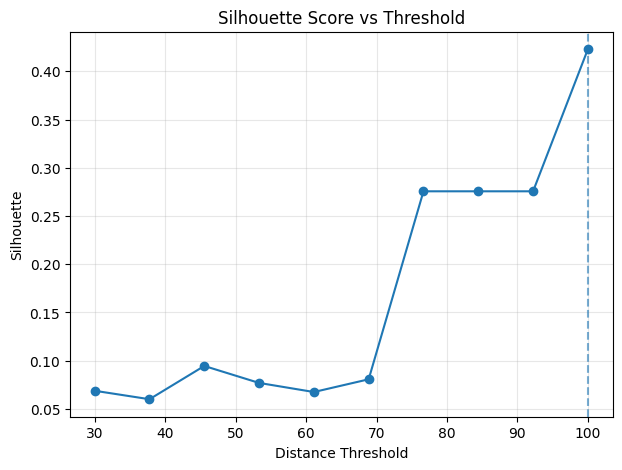

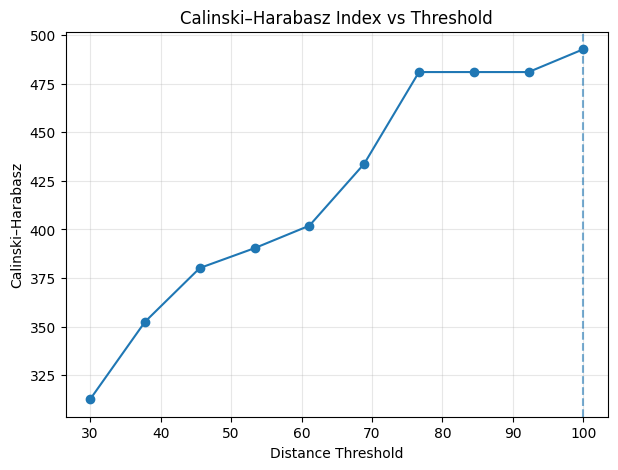

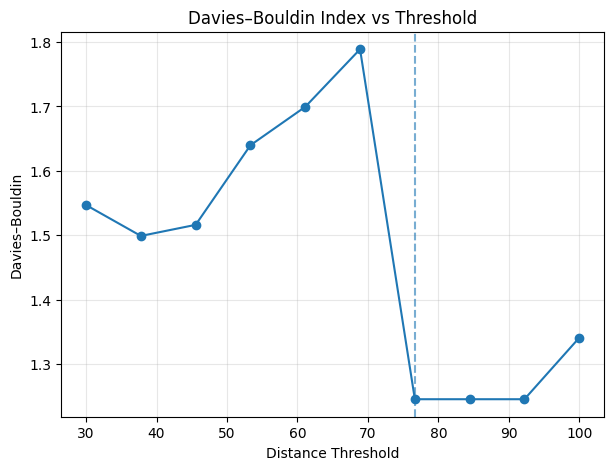

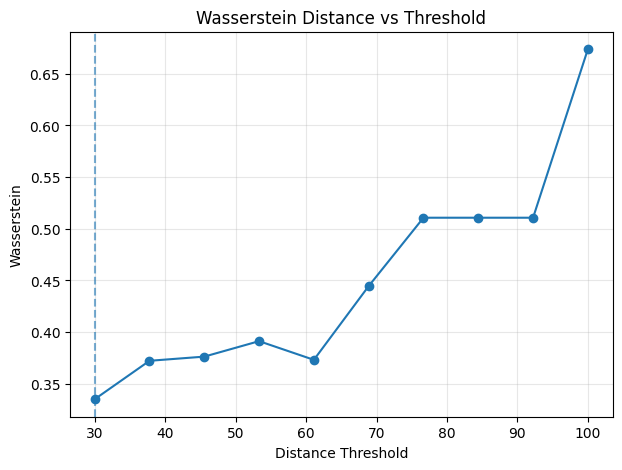

Per-metric winners: {'silhouette': 100.0, 'calinski_harabasz': 100.0, 'davies_bouldin': 76.66666666666666, 'wasserstein': 30.0}
Suggested threshold (ensemble): 100.00
Stability-picked Ward threshold = 100.00
Best-by votes:
  silhouette          : 100.00
  calinski_harabasz   : 100.00
  davies_bouldin      : 100.00
  wasserstein         : 100.00
Ward linkage: 3 clusters found using distance threshold = 100.0

Analyzing clusters using features: ['pca_component_1', 'pca_component_2', 'pca_component_3', 'pca_component_4', 'pca_component_5', 'pca_component_6', 'pca_component_7', 'pca_component_8', 'pca_component_9', 'pca_component_10', 'pca_component_11', 'pca_component_12']

Cluster Statistics:
shape: (3, 50)
┌─────────┬───────┬────────────┬────────────┬───┬────────────┬────────────┬────────────┬───────────┐
│ cluster ┆ count ┆ pca_compon ┆ pca_compon ┆ … ┆ pca_compon ┆ pca_compon ┆ pca_compon ┆ pca_compo │
│ ---     ┆ ---   ┆ ent_1_mean ┆ ent_2_mean ┆   ┆ ent_9_max  ┆ ent_10_max ┆ ent_11_

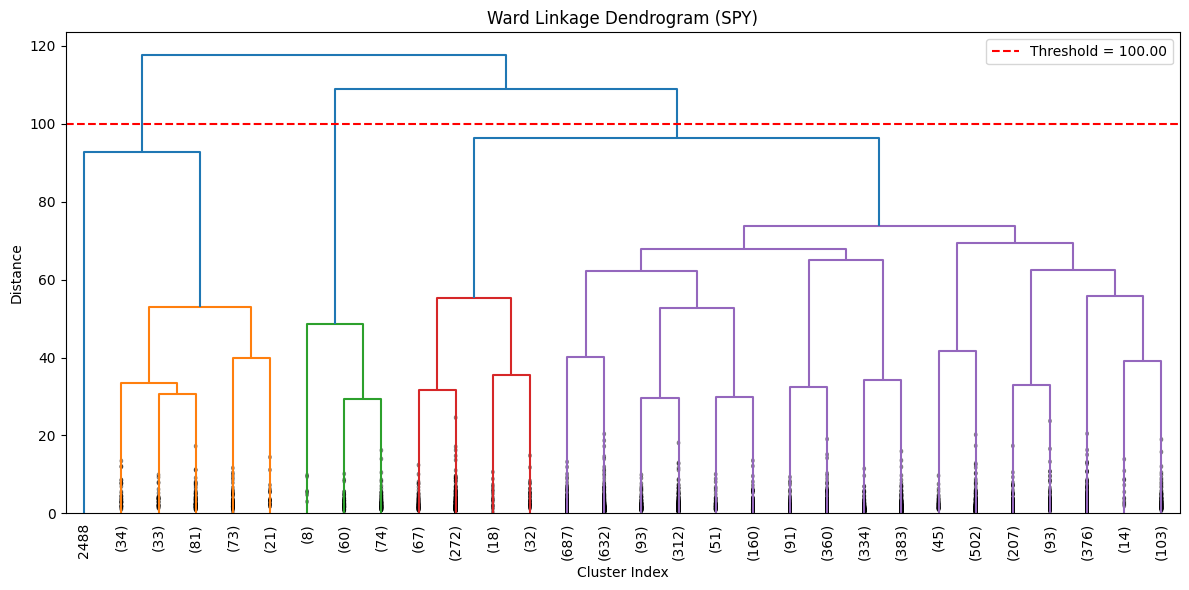

In [20]:
# SPY pipeline using Ward Linkage

path = "./parquet/spy_historical_2005_2023.parquet"

# 1) Load
sample_ward_spy = lazy_sample_parquet(path, fraction=0.0001, columns=numeric_features)

# 2) PCA (once)
result_ward_spy, pca_obj_spy, pca_cols_spy = apply_pca_preprocessing(sample_ward_spy, numeric_features)
# loadings_qqq = pd.DataFrame(pca_obj_qqq.components_, columns=numeric_features)
# loadings_qqq.index = [f'PC{i+1}' for i in range(loadings_qqq.shape[0])]
# print("PCA Loadings (each row = PC, each column = feature weight):")
# display(loadings_qqq.head())

# 3) Precompute features once
X_spy = _prep_features(result_ward_spy, pca_cols_spy, standardize=False, dtype=np.float32)

# 4) Try a few distance thresholds
thresholds = np.linspace(30, 100, 10).tolist()

# 5) Fast scan + weight search (cached stability)
res_spy = scan_ward_thresholds(X=X_spy, thresholds=thresholds, sample_size=5000)

alpha_spy, beta_spy, best_thresh_spy, summary_spy = optimize_w_weights_by_stability_ward(
    thresholds=res_spy["thresholds"],
    res=res_spy,
    X=X_spy
)
print(f"SPY: α={alpha_spy}, β={beta_spy} → threshold*={best_thresh_spy} (mean ARI={summary_spy['best']['score']:.3f})")

# (Optional) diagnostics using the chosen weights
plot_ward_scan(res_spy)

best_spy_ward_res = scan_ward_thresholds(X=X_spy, thresholds=[best_thresh_spy], sample_size=5000)

# Final clustering from precomputed X
clustered_ward_auto_spy_df = perform_clustering_from_X(
    X=X_spy,
    df=result_ward_spy,
    method="ward",
    distance_threshold=best_thresh_spy,
    n_clusters=None  # ignored for Ward
)

# Analyze cluster characteristics
cluster_ward_stats_spy_auto = analyze_clusters(
    df=clustered_ward_auto_spy_df,
    feature_cols=feature_set,
    cluster_col="cluster"
)

# (Optional) Plot dendogram
plot_dendogram(X_spy, best_thresh_spy)

#save clustered_ward_auto_spy_df to parquet
clustered_ward_auto_spy_df.write_parquet("./parquet/clustered_ward_auto_spy_df.parquet")

In [21]:
plot_cols = build_plot_cols(feature_set=pca_cols_spy, label_col="cluster", max_feats=8)
plot_cols += [c for c in extra_cols if c not in plot_cols and c in clustered_ward_auto_spy_df.columns]
df_plot_spy = to_pandas_minimal(clustered_ward_auto_spy_df, plot_cols, label_col="cluster")
for dtc in ("date", "timestamp", "datetime"):
    if dtc in df_plot_spy.columns and not pd.api.types.is_datetime64_any_dtype(df_plot_spy[dtc]):
        df_plot_spy[dtc] = pd.to_datetime(df_plot_spy[dtc], errors="coerce")
regime_dashboard_windows(df=df_plot_spy, label_col="cluster")

In [34]:
sample_ward_qqq = lazy_sample_parquet(path, fraction=1, columns=numeric_features)
sample_ward_qqq.info()

Sampling ≈100.0% of rows (columns=16)
Loaded 20,204,265 rows out of 20,204,265


AttributeError: 'DataFrame' object has no attribute 'info'

Sampling ≈0.0% of rows (columns=16)
Loaded 2,020 rows out of 20,204,265
PCA reduced 16 → 13 comps (explained=0.969)
Stability-picked Ward threshold = 30.00
Best-by votes:
  silhouette          : 76.67
  calinski_harabasz   : 76.67
  davies_bouldin      : 30.00
  wasserstein         : 30.00
Normalizing silhouette and Davies–Bouldin metrics...
Computing stability for 8 thresholds in parallel...
Computing stability for threshold=30.00...
Computing stability for threshold=37.78...
Computing stability for threshold=45.56...
Computing stability for threshold=53.33...
Computing stability for threshold=61.11...
Computing stability for threshold=68.89...
Computing stability for threshold=76.67...
Computing stability for threshold=84.44...
Best stability 1.0000 at alpha=0.25, beta=0.25, threshold=76.67
QQQ: α=0.25, β=0.25 → threshold*=76.66666666666666 (mean ARI=1.000)


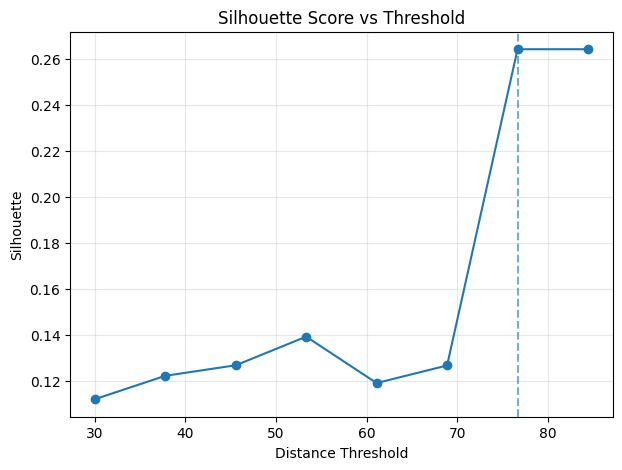

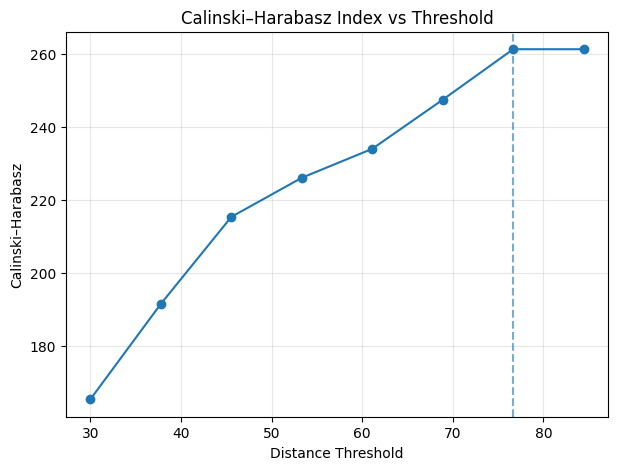

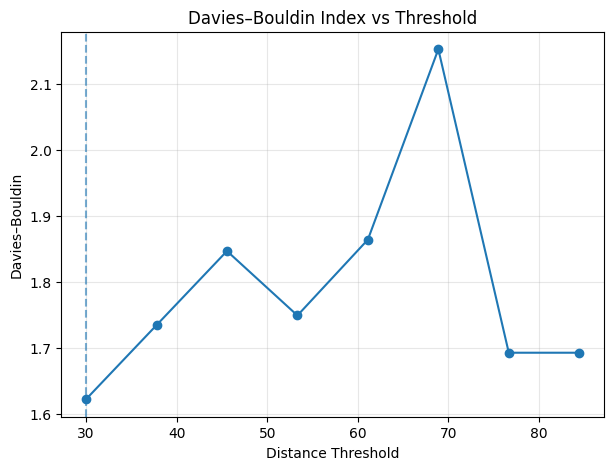

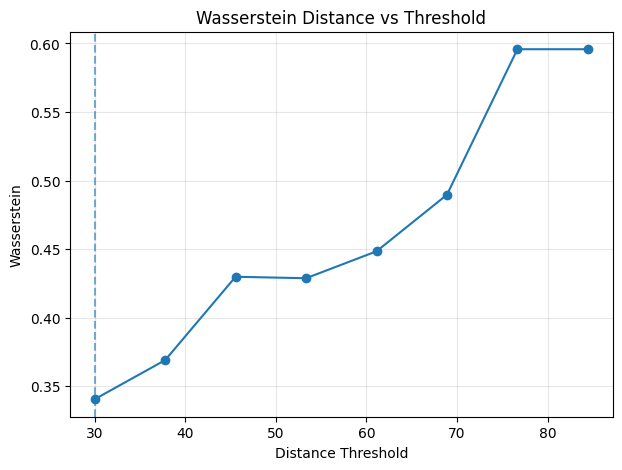

Per-metric winners: {'silhouette': 76.66666666666666, 'calinski_harabasz': 76.66666666666666, 'davies_bouldin': 30.0, 'wasserstein': 30.0}
Suggested threshold (ensemble): 30.00
Stability-picked Ward threshold = 76.67
Best-by votes:
  silhouette          : 76.67
  calinski_harabasz   : 76.67
  davies_bouldin      : 76.67
  wasserstein         : 76.67
Ward linkage: 2 clusters found using distance threshold = 76.66666666666666

Analyzing clusters using features: ['pca_component_1', 'pca_component_2', 'pca_component_3', 'pca_component_4', 'pca_component_5', 'pca_component_6', 'pca_component_7', 'pca_component_8', 'pca_component_9', 'pca_component_10', 'pca_component_11', 'pca_component_12']

Cluster Statistics:
shape: (2, 50)
┌─────────┬───────┬────────────┬────────────┬───┬────────────┬────────────┬────────────┬───────────┐
│ cluster ┆ count ┆ pca_compon ┆ pca_compon ┆ … ┆ pca_compon ┆ pca_compon ┆ pca_compon ┆ pca_compo │
│ ---     ┆ ---   ┆ ent_1_mean ┆ ent_2_mean ┆   ┆ ent_9_max  ┆ ent

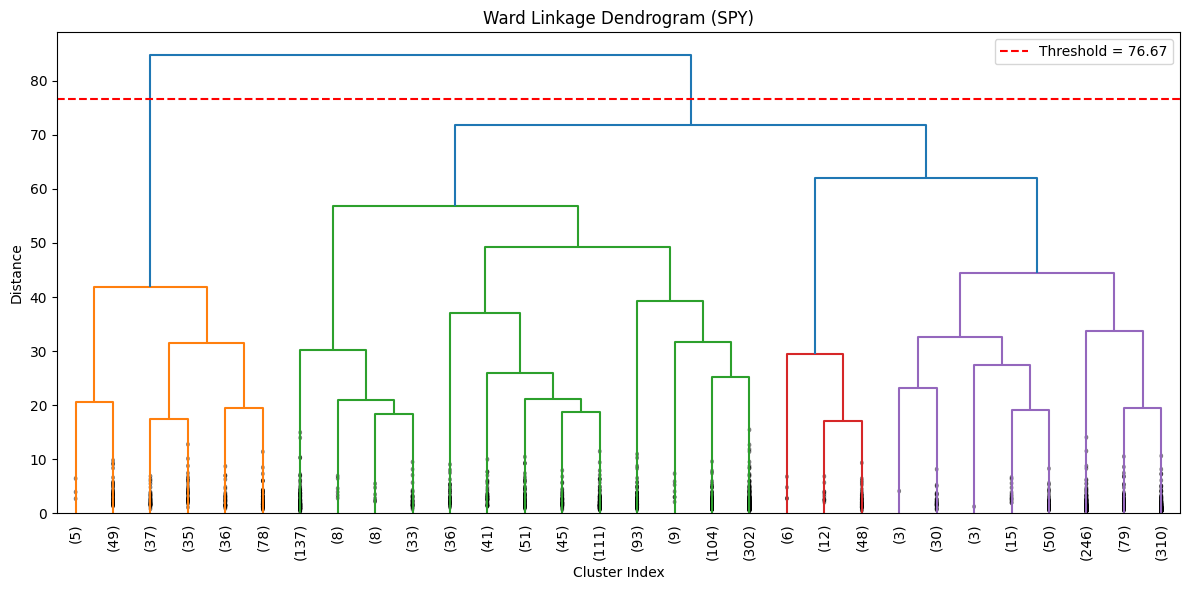

In [22]:
# QQQ pipeline using Ward Linkage

path = "./parquet/qqq_historical_2005_2023.parquet"

# 1) Load
sample_ward_qqq = lazy_sample_parquet(path, fraction=0.0001, columns=numeric_features)
sample_ward_qqq.head()

# 2) PCA (once)
result_ward_qqq, pca_obj_qqq, pca_cols_qqq = apply_pca_preprocessing(sample_ward_qqq, numeric_features)
# loadings_qqq = pd.DataFrame(pca_obj_qqq.components_, columns=numeric_features)
# loadings_qqq.index = [f'PC{i+1}' for i in range(loadings_qqq.shape[0])]
# print("PCA Loadings (each row = PC, each column = feature weight):")
# display(loadings_qqq.head())

# 3) Precompute features once
X_qqq = _prep_features(result_ward_qqq, pca_cols_qqq, standardize=False, dtype=np.float32)

# 4) Try a few distance thresholds
thresholds = np.linspace(30, 100, 10).tolist()

# 5) Fast scan + weight search (cached stability)
res_qqq = scan_ward_thresholds(X=X_qqq, thresholds=thresholds, sample_size=5000)

alpha_qqq, beta_spy, best_thresh_qqq, summary_qqq = optimize_w_weights_by_stability_ward(
    thresholds=res_qqq["thresholds"],
    res=res_qqq,
    X=X_qqq
)
print(f"QQQ: α={alpha_qqq}, β={beta_qqq} → threshold*={best_thresh_qqq} (mean ARI={summary_qqq['best']['score']:.3f})")

# (Optional) diagnostics using the chosen weights
plot_ward_scan(res_qqq)

best_qqq_ward_res = scan_ward_thresholds(X=X_qqq, thresholds=[best_thresh_qqq], sample_size=5000)

# Final clustering from precomputed X
clustered_ward_auto_qqq_df = perform_clustering_from_X(
    X=X_qqq,
    df=result_ward_qqq,
    method="ward",
    distance_threshold=best_thresh_qqq,
    n_clusters=None  # ignored for Ward
)

# Analyze cluster characteristics
cluster_ward_stats_qqq_auto = analyze_clusters(
    df=clustered_ward_auto_qqq_df,
    feature_cols=feature_set,
    cluster_col="cluster"
)

# (Optional) Plot dendogram
plot_dendogram(X_qqq, best_thresh_qqq)

#save clustered_ward_auto_qqq_df to parquet
clustered_ward_auto_qqq_df.write_parquet("./parquet/clustered_ward_auto_qqq_df.parquet")

In [23]:
plot_cols = build_plot_cols(feature_set=pca_cols_qqq, label_col="cluster", max_feats=8)
plot_cols += [c for c in extra_cols if c not in plot_cols and c in clustered_ward_auto_qqq_df.columns]
df_plot_qqq = to_pandas_minimal(clustered_ward_auto_qqq_df, plot_cols, label_col="cluster")
for dtc in ("date", "timestamp", "datetime"):
    if dtc in df_plot_qqq.columns and not pd.api.types.is_datetime64_any_dtype(df_plot_qqq[dtc]):
        df_plot_qqq[dtc] = pd.to_datetime(df_plot_qqq[dtc], errors="coerce")
regime_dashboard_windows(df=df_plot_qqq, label_col="cluster")

## Summary of Results

In [24]:
summary = pd.DataFrame([
    {
        "Ticker": "SPY",
        "Method": "KMeans",
        "Best Parameter": f"k = {k_star}",
        "Number of Clusters": clustered_auto_df.select(pl.col("cluster").n_unique()).item(),
        "Silhouette Score": best_spy_k_res.silhouette[0],
        "Calinski-Harabasz Score": best_spy_k_res.calinski_harabasz[0],
        "Davies-Bouldin Score": best_spy_k_res.davies_bouldin[0],
        "Wasserstein distance": best_spy_k_res.w_distance[0],
        "Stability (ARI)": info['best']['score']
    },
    {
        "Ticker": "SPY",
        "Method": "Ward Linkage",
        "Best Parameter": f"threshold = {best_thresh_spy:.2f}",
        "Number of Clusters": clustered_ward_auto_spy_df.select(pl.col("cluster").n_unique()).item(),
        "Silhouette Score": best_spy_ward_res["silhouette"][0],
        "Calinski-Harabasz Score": best_spy_ward_res["calinski_harabasz"][0],
        "Davies-Bouldin Score": best_spy_ward_res["davies_bouldin"][0],
        "Wasserstein distance": best_spy_ward_res["wasserstein"][0],
        "Stability (ARI)": summary_spy['best']['score']
    },
    {
        "Ticker": "QQQ",
        "Method": "KMeans",
        "Best Parameter": f"k = {k_star_qqq}",
        "Number of Clusters": clustered_auto_qqq_df.select(pl.col("cluster").n_unique()).item(),
        "Silhouette Score": best_qqq_k_res.silhouette[0],
        "Calinski-Harabasz Score": best_qqq_k_res.calinski_harabasz[0],
        "Davies-Bouldin Score": best_qqq_k_res.davies_bouldin[0],
        "Wasserstein distance": best_qqq_k_res.w_distance[0],
        "Stability (ARI)": info_qqq['best']['score']
    },
    {
        "Ticker": "QQQ",
        "Method": "Ward Linkage",
        "Best Parameter": f"threshold = {best_thresh_qqq:.2f}",
        "Number of Clusters": clustered_ward_auto_qqq_df.select(pl.col("cluster").n_unique()).item(),
        "Silhouette Score": best_qqq_ward_res["silhouette"][0],
        "Calinski-Harabasz Score": best_qqq_ward_res["calinski_harabasz"][0],
        "Davies-Bouldin Score": best_qqq_ward_res["davies_bouldin"][0],
        "Wasserstein distance": best_qqq_ward_res["wasserstein"][0],
        "Stability (ARI)": summary_qqq['best']['score']
    }
])
display(summary)

,Ticker,Method,Best Parameter,Number of Clusters,Silhouette Score,Calinski-Harabasz Score,Davies-Bouldin Score,Wasserstein distance,Stability (ARI)
0,SPY,KMeans,k = 8,8,0.137963,5099.364084,1.595549,1.000000,0.761860
1,SPY,Ward Linkage,threshold = 100.00,3,0.422911,492.751808,1.340900,0.673736,1.000000
2,QQQ,KMeans,k = 2,2,0.322892,1718.294008,1.808942,1.000000,0.977651
3,QQQ,Ward Linkage,threshold = 76.67,2,0.264239,261.267411,1.692705,0.595797,1.000000


__Cluster Size Comparison__

/var/folders/g0/21_2mymx5mn788q92btxg65m0000gn/T/ipykernel_68408/1281259518.py:2: DeprecationWarning: `GroupBy.count` was renamed; use `GroupBy.len` instead
  kmeans_spy_sizes = clustered_auto_df.group_by("cluster").count().sort("cluster")
/var/folders/g0/21_2mymx5mn788q92btxg65m0000gn/T/ipykernel_68408/1281259518.py:3: DeprecationWarning: `GroupBy.count` was renamed; use `GroupBy.len` instead
  ward_spy_sizes = clustered_ward_auto_spy_df.group_by("cluster").count().sort("cluster")
/var/folders/g0/21_2mymx5mn788q92btxg65m0000gn/T/ipykernel_68408/1281259518.py:4: DeprecationWarning: `GroupBy.count` was renamed; use `GroupBy.len` instead
  kmeans_qqq_sizes = clustered_auto_qqq_df.group_by("cluster").count().sort("cluster")
/var/folders/g0/21_2mymx5mn788q92btxg65m0000gn/T/ipykernel_68408/1281259518.py:5: DeprecationWarning: `GroupBy.count` was renamed; use `GroupBy.len` instead
  ward_qqq_sizes = clustered_ward_auto_qqq_df.group_by("cluster").count().sort("cluster")


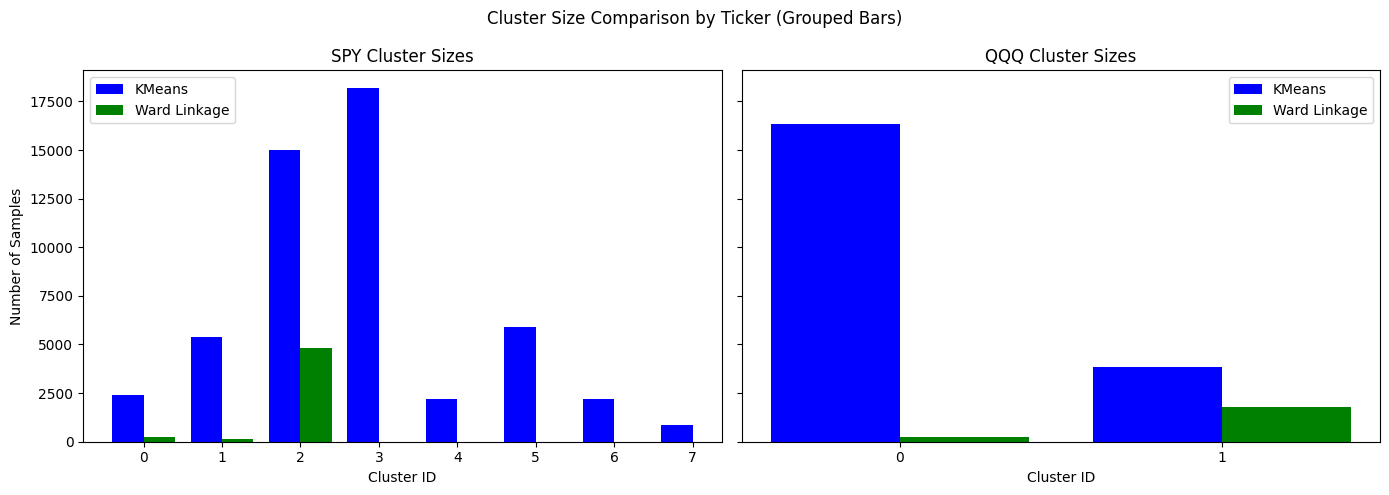

In [25]:
# Step 1: Compute cluster sizes
kmeans_spy_sizes = clustered_auto_df.group_by("cluster").count().sort("cluster")
ward_spy_sizes = clustered_ward_auto_spy_df.group_by("cluster").count().sort("cluster")
kmeans_qqq_sizes = clustered_auto_qqq_df.group_by("cluster").count().sort("cluster")
ward_qqq_sizes = clustered_ward_auto_qqq_df.group_by("cluster").count().sort("cluster")

# Step 2: Convert to pandas Series
def convert_sizes(pl_df):
    df = pl_df.to_pandas()
    return df.set_index("cluster")["count"]

kmeans_spy = convert_sizes(kmeans_spy_sizes)
ward_spy = convert_sizes(ward_spy_sizes)
kmeans_qqq = convert_sizes(kmeans_qqq_sizes)
ward_qqq = convert_sizes(ward_qqq_sizes)

# Step 3: Align cluster IDs and fill missing with 0
all_spy_clusters = sorted(set(kmeans_spy.index).union(ward_spy.index))
all_qqq_clusters = sorted(set(kmeans_qqq.index).union(ward_qqq.index))

kmeans_spy = kmeans_spy.reindex(all_spy_clusters)
ward_spy = ward_spy.reindex(all_spy_clusters)
kmeans_qqq = kmeans_qqq.reindex(all_qqq_clusters)
ward_qqq = ward_qqq.reindex(all_qqq_clusters)

# Step 4: Plot grouped bars
bar_width = 0.4
x_spy = np.arange(len(all_spy_clusters))
x_qqq = np.arange(len(all_qqq_clusters))

fig, axs = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# SPY subplot
axs[0].bar(x_spy - bar_width/2, kmeans_spy.values, width=bar_width, label="KMeans", color="blue")
axs[0].bar(x_spy + bar_width/2, ward_spy.values, width=bar_width, label="Ward Linkage", color="green")
axs[0].set_xticks(x_spy)
axs[0].set_xticklabels(all_spy_clusters)
axs[0].set_title("SPY Cluster Sizes")
axs[0].set_xlabel("Cluster ID")
axs[0].set_ylabel("Number of Samples")
axs[0].legend()

# QQQ subplot
axs[1].bar(x_qqq - bar_width/2, kmeans_qqq.values, width=bar_width, label="KMeans", color="blue")
axs[1].bar(x_qqq + bar_width/2, ward_qqq.values, width=bar_width, label="Ward Linkage", color="green")
axs[1].set_xticks(x_qqq)
axs[1].set_xticklabels(all_qqq_clusters)
axs[1].set_title("QQQ Cluster Sizes")
axs[1].set_xlabel("Cluster ID")
axs[1].legend()

plt.suptitle("Cluster Size Comparison by Ticker (Grouped Bars)")
plt.tight_layout()
plt.show()


__Radar Chart of Metrics__

SPY_KMeans:
  Silhouette: 0.0000
  Calinski-Harabasz: 1.0000
  1 / Davies-Bouldin: 0.3832
  1 / Wasserstein: 0.0000

SPY_Ward:
  Silhouette: 1.0000
  Calinski-Harabasz: 0.0478
  1 / Davies-Bouldin: 1.0000
  1 / Wasserstein: 0.7138

QQQ_KMeans:
  Silhouette: 0.6490
  Calinski-Harabasz: 0.3012
  1 / Davies-Bouldin: 0.0000
  1 / Wasserstein: 0.0000

QQQ_Ward:
  Silhouette: 0.4432
  Calinski-Harabasz: 0.0000
  1 / Davies-Bouldin: 0.1967
  1 / Wasserstein: 1.0000



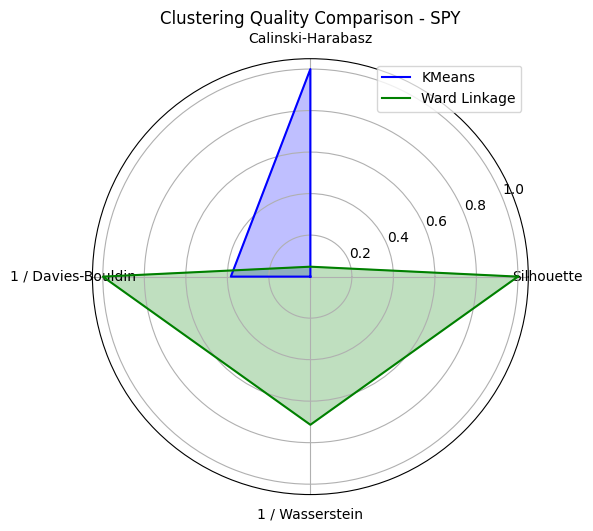

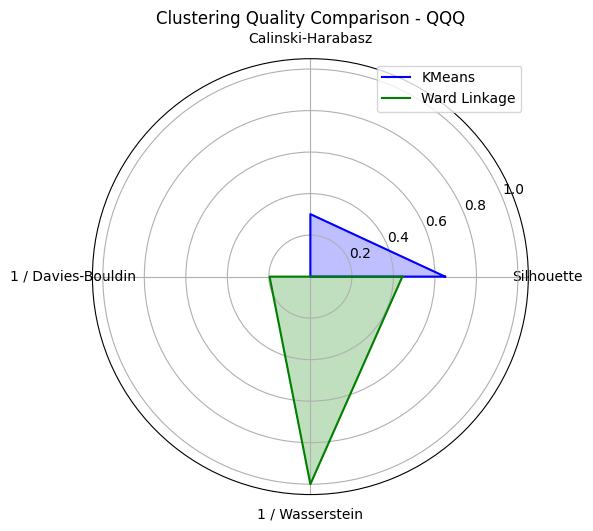

In [26]:
# Step 1: Define metric labels
labels = ["Silhouette", "Calinski-Harabasz", "1 / Davies-Bouldin", "1 / Wasserstein"]

# Step 2: Collect raw metrics
raw_metrics = {
    "SPY_KMeans": [
        best_spy_k_res.silhouette[0],
        best_spy_k_res.calinski_harabasz[0],
        1 / best_spy_k_res.davies_bouldin[0],
        1 / best_spy_k_res.w_distance[0]
    ],
    "SPY_Ward": [
        best_spy_ward_res["silhouette"][0],
        best_spy_ward_res["calinski_harabasz"][0],
        1 / best_spy_ward_res["davies_bouldin"][0],
        1 / best_spy_ward_res["wasserstein"][0]
    ],
    "QQQ_KMeans": [
        best_qqq_k_res.silhouette[0],
        best_qqq_k_res.calinski_harabasz[0],
        1 / best_qqq_k_res.davies_bouldin[0],
        1 / best_qqq_k_res.w_distance[0]
    ],
    "QQQ_Ward": [
        best_qqq_ward_res["silhouette"][0],
        best_qqq_ward_res["calinski_harabasz"][0],
        1 / best_qqq_ward_res["davies_bouldin"][0],
        1 / best_qqq_ward_res["wasserstein"][0]
    ]
}

# Step 3: Normalize each metric across all methods
def normalize_all(metrics_dict):
    # Transpose to group by metric
    all_metrics = np.array(list(metrics_dict.values()))
    transposed = all_metrics.T  # shape: (num_metrics, num_methods)

    # Normalize each metric across all methods
    normalized = []
    for metric_values in transposed:
        min_val = np.min(metric_values)
        max_val = np.max(metric_values)
        range_val = max_val - min_val if max_val != min_val else 1.0
        normalized.append([(v - min_val) / range_val for v in metric_values])

    # Transpose back to method-wise
    normalized_metrics = np.array(normalized).T
    return dict(zip(metrics_dict.keys(), normalized_metrics.tolist()))

normalized_metrics = normalize_all(raw_metrics)

# Print normalized metrics for inspection
for method, values in normalized_metrics.items():
    print(f"{method}:")
    for label, value in zip(labels, values):
        print(f"  {label}: {value:.4f}")
    print()


# Step 4: Plot radar chart
def plot_radar(labels, m1, m2, title):
    angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
    angles += angles[:1]
    m1 += m1[:1]
    m2 += m2[:1]

    fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
    ax.plot(angles, m1, label="KMeans", color="blue")
    ax.fill(angles, m1, alpha=0.25, color="blue")
    ax.plot(angles, m2, label="Ward Linkage", color="green")
    ax.fill(angles, m2, alpha=0.25, color="green")

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels)
    ax.set_title(title)
    ax.legend(loc="upper right")
    plt.tight_layout()
    plt.show()

# Step 5: Run for SPY and QQQ
plot_radar(
    labels,
    normalized_metrics["SPY_KMeans"],
    normalized_metrics["SPY_Ward"],
    "Clustering Quality Comparison - SPY"
)

plot_radar(
    labels,
    normalized_metrics["QQQ_KMeans"],
    normalized_metrics["QQQ_Ward"],
    "Clustering Quality Comparison - QQQ"
)


In [7]:
# Load a Parquet file
df = pl.read_parquet("./parquet/qqq_historical_2005_2023_v1.parquet")

# Preview the data
print(df.shape)

(7041111, 37)


In [8]:
# Load a Parquet file
df = pl.read_parquet("./parquet/spy_historical_2005_2023.parquet")

# Preview the data
print(df.shape)

(52176345, 36)
